In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [288]:
df = pd.read_csv('Stars.csv')

In [289]:
df.sample(5)

,Temperature,L,R,A_M,Color,Spectral_Class,Type
70,3345,0.02100,0.273,12.30,Red,M,1
230,24145,382993.00000,1494.000,-8.84,Blue-white,B,5
44,3008,280000.00000,25.000,-6.00,Red,M,4
196,3142,0.00132,0.258,14.12,Red,M,1
37,6380,1.35000,0.980,2.93,yellow-white,F,3


In [290]:
df.shape

(240, 7)

In [291]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 14.7 KB


In [292]:
df.isnull().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
Type              0
dtype: int64

In [293]:
df.describe()

,Temperature,L,R,A_M,Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [294]:
df['Color'] = df['Color'].str.lower()
df['Color'] = df['Color'].str.replace('-', ' ')

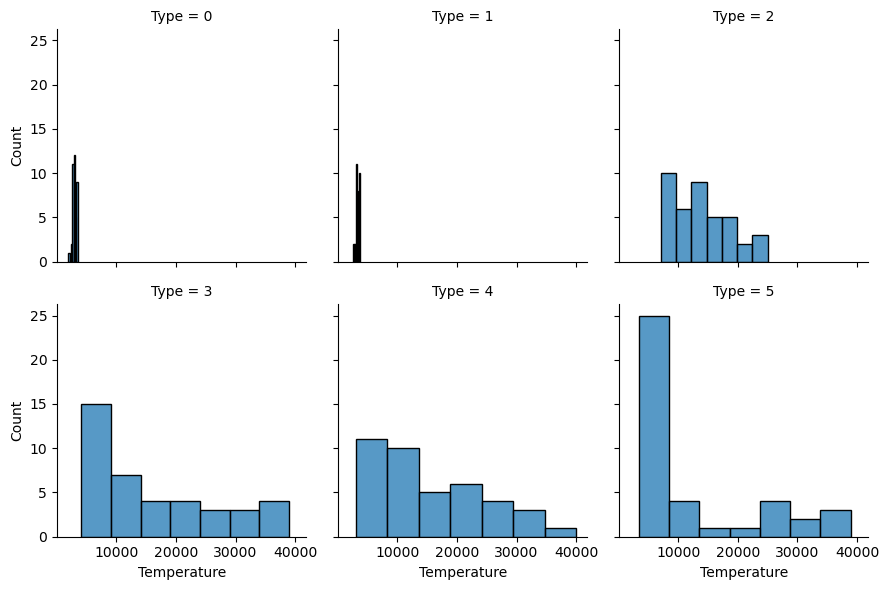

In [295]:
g = sns.FacetGrid(df, col='Type', col_wrap=3)
g.map(sns.histplot, 'Temperature')

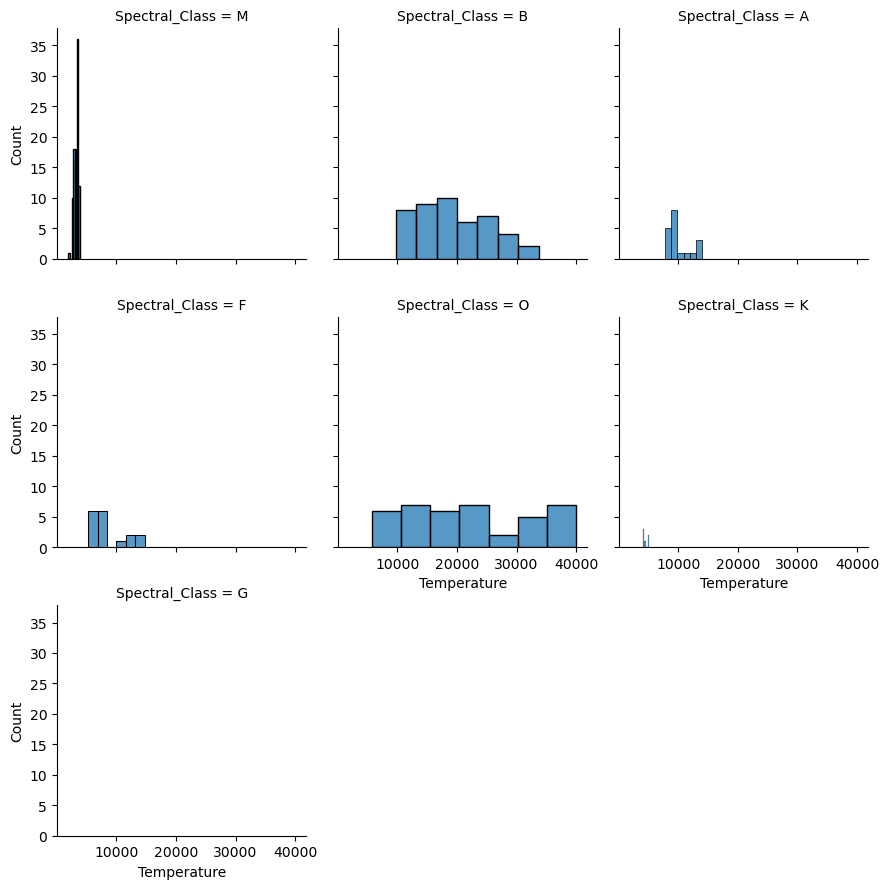

In [296]:
g = sns.FacetGrid(df, col='Spectral_Class', col_wrap=3)
g.map(sns.histplot, 'Temperature')

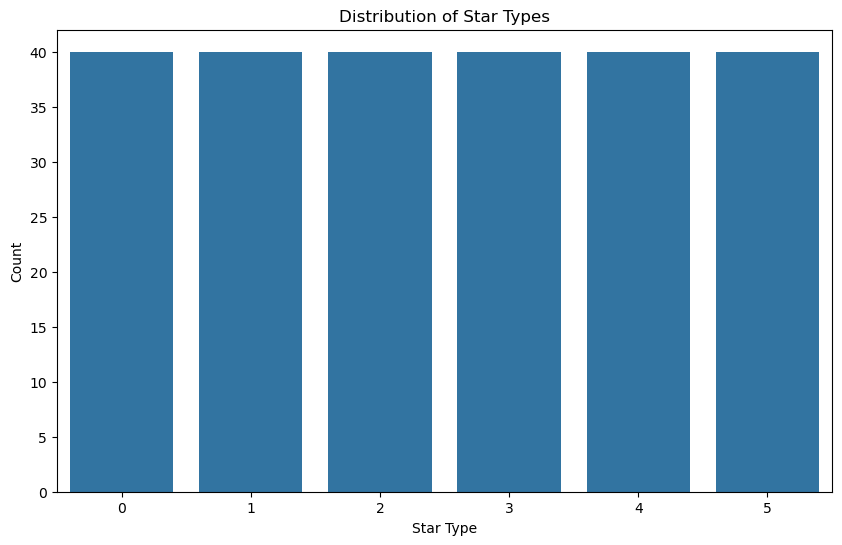

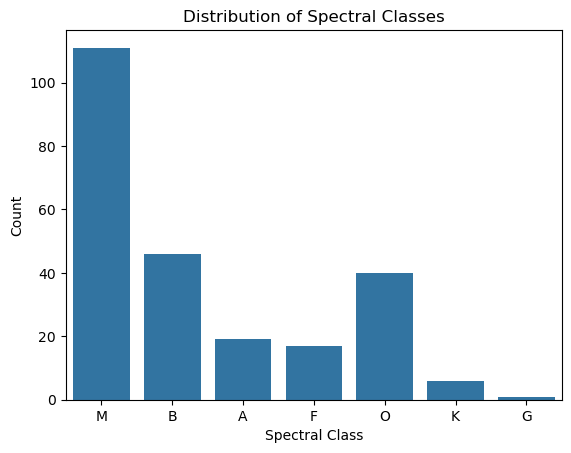

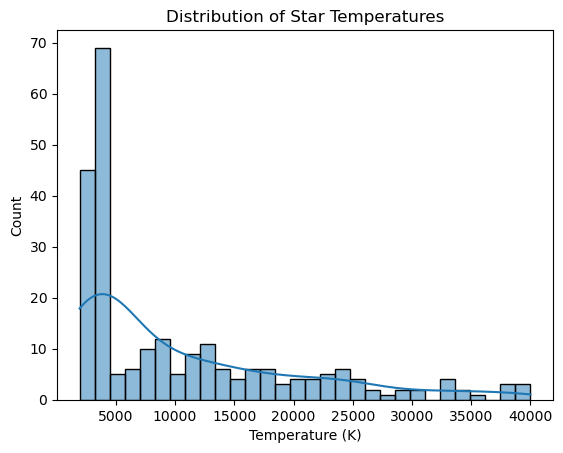

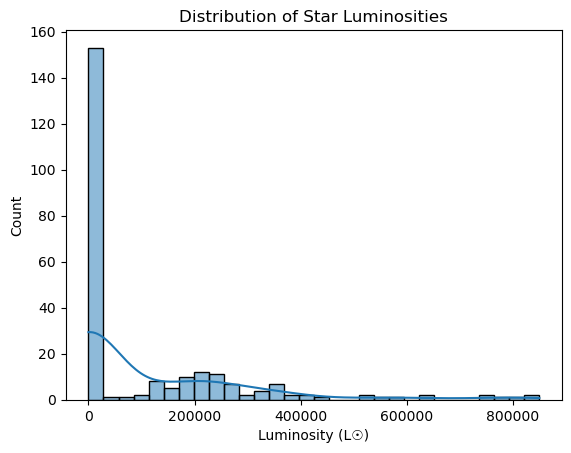

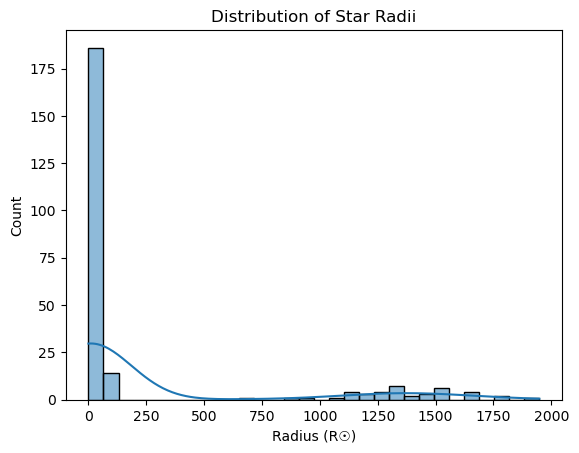

In [297]:
# univariate analysis

# distribution of star types
plt.figure(figsize=(10,6))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Star Types')
plt.xlabel('Star Type')
plt.ylabel('Count')
plt.show()

# distribution of spectral classes
sns.countplot(x='Spectral_Class', data=df)
plt.title('Distribution of Spectral Classes')
plt.xlabel('Spectral Class')
plt.ylabel('Count')
plt.show()

# distribution of temperatures
sns.histplot(df['Temperature'], bins=30, edgecolor='black',kde=True)
plt.title('Distribution of Star Temperatures')
plt.xlabel('Temperature (K)')
plt.ylabel('Count')
plt.show()

# distribution of luminosities
sns.histplot(df['L'], bins=30, edgecolor='black', kde=True)
plt.title('Distribution of Star Luminosities')
plt.xlabel('Luminosity (L☉)')
plt.ylabel('Count')
plt.show()

# distribution of radii
sns.histplot(df['R'], bins=30, edgecolor='black', kde=True)
plt.title('Distribution of Star Radii')
plt.xlabel('Radius (R☉)')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Type', ylabel='Temperature'>

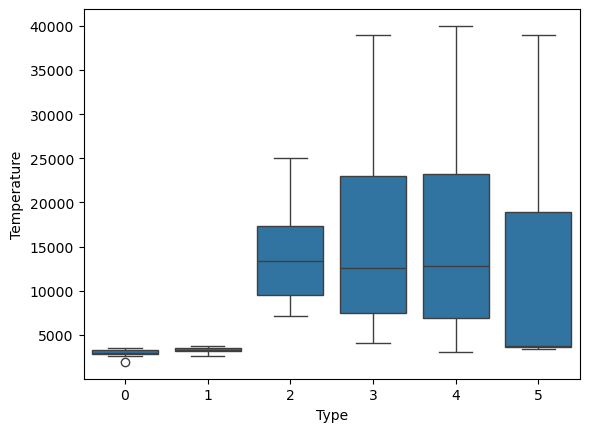

In [298]:
# bivariate analysis
sns.boxplot(x='Type', y='Temperature', data=df)

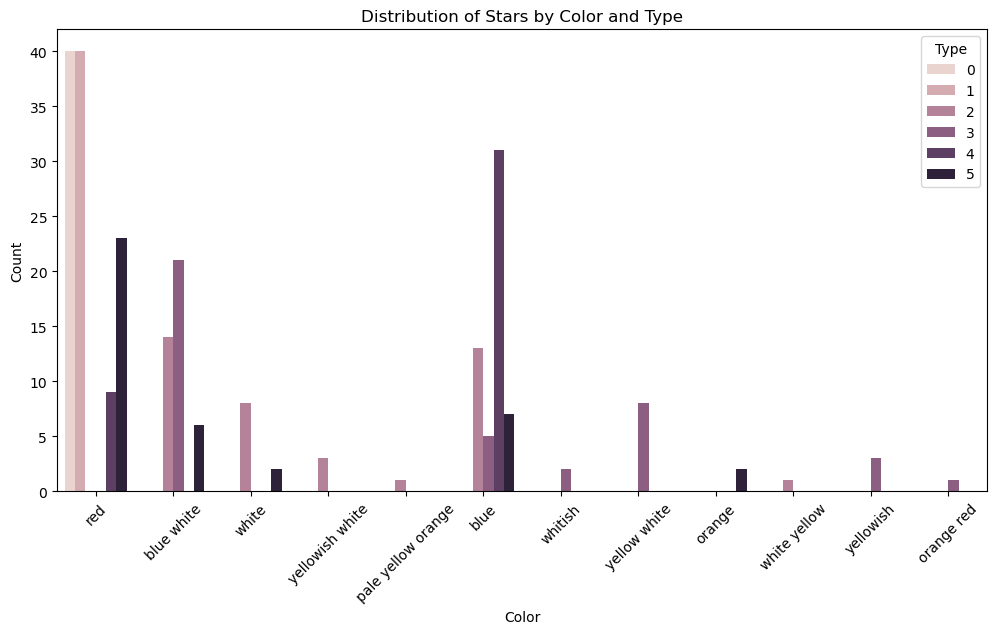

In [299]:
plt.figure(figsize=(12,6))
sns.countplot(x='Color', hue='Type', data=df)
plt.title('Distribution of Stars by Color and Type')
plt.xlabel('Color')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

<Axes: >

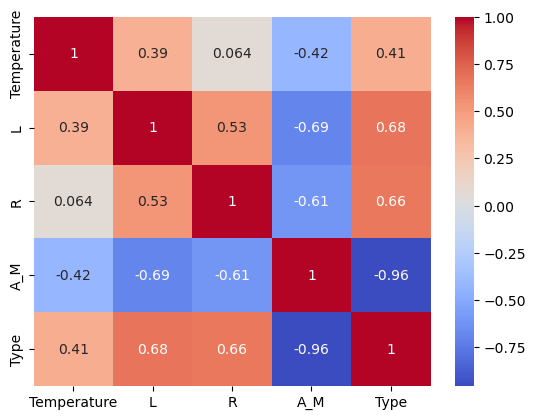

In [300]:
# checking correlations
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [301]:
# Separating features and target variable
X = df.drop(columns=['Type'])
y = df['Type']

In [302]:
# split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [303]:
# since our dataset has categorical fetures, we need to encode them before feeding into the model

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler


In [304]:
df['Color'].unique()

<ArrowStringArray>
[               'red',         'blue white',              'white',
    'yellowish white', 'pale yellow orange',               'blue',
            'whitish',       'yellow white',             'orange',
       'white yellow',          'yellowish',         'orange red']
Length: 12, dtype: str

In [305]:
# colunn transformer to encode categorical features and scale numerical features
trf = ColumnTransformer([
    
    ('color_ohe',
     OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     ['Color']),
    
    ('spectral_ohe',
     OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     ['Spectral_Class']),

    ('scale', MinMaxScaler(), ['Temperature', 'L', 'R', 'A_M'])

], remainder='passthrough')

In [306]:

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
# Building a pipeline with the column transformer and a classifier
pipe = Pipeline([
    ('preprocessor', trf),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [307]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('color_ohe', ...), ('spectral_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

In [308]:
y_pred = pipe.predict(X_test)

In [309]:
# evaluating the model accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [310]:
X.columns

Index(['Temperature', 'L', 'R', 'A_M', 'Color', 'Spectral_Class'], dtype='str')

In [311]:
train_score = pipe.score(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Train Accuracy: 1.0
Test Accuracy: 1.0


# Random Forest Model

In [312]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipe_rf = Pipeline([
    ('preprocessor', trf),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
accuracy_score(y_test, y_pred_rf)
print(accuracy)

1.0


In [313]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X, y, cv=10)
print(f'score_mean: {scores.mean()}')
print(f'scores: {scores}')

score_mean: 0.9958333333333333
scores: [1.         1.         1.         0.95833333 1.         1.
 1.         1.         1.         1.        ]


/home/leo/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/leo/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/leo/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [314]:
# feature importance


# extracting the model
model = pipe.named_steps['classifier']

feature_importance = model.feature_importances_

feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

In [317]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

In [320]:
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [322]:
print(feature_importance_df)

                                Feature  Importance
20                           scale__A_M         0.6
17                   scale__Temperature         0.2
19                             scale__R         0.2
1               color_ohe__Color_orange         0.0
0           color_ohe__Color_blue white         0.0
4                  color_ohe__Color_red         0.0
3   color_ohe__Color_pale yellow orange         0.0
2           color_ohe__Color_orange red         0.0
5                color_ohe__Color_white         0.0
9            color_ohe__Color_yellowish         0.0
6         color_ohe__Color_white yellow         0.0
7              color_ohe__Color_whitish         0.0
8         color_ohe__Color_yellow white         0.0
12       spectral_ohe__Spectral_Class_F         0.0
11       spectral_ohe__Spectral_Class_B         0.0
10     color_ohe__Color_yellowish white         0.0
13       spectral_ohe__Spectral_Class_G         0.0
16       spectral_ohe__Spectral_Class_O         0.0
15       spe

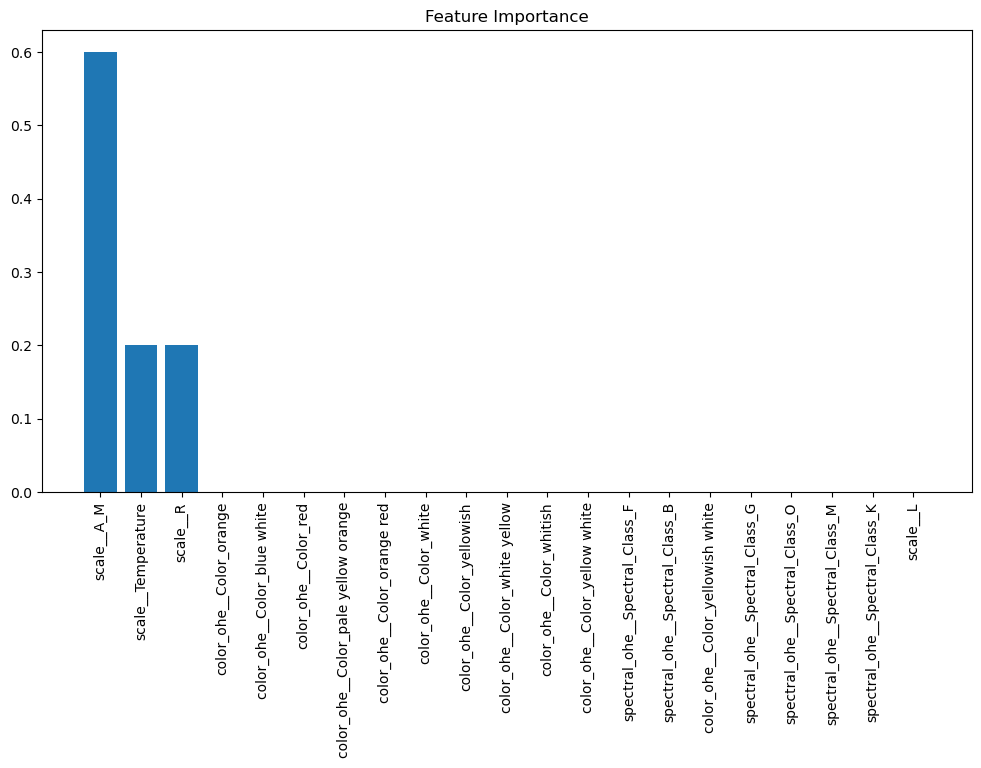

In [324]:
plt.figure(figsize=(12,6))

plt.bar(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.xticks(rotation=90)

plt.title('Feature Importance')

plt.show()